# Подготовка датасета Lenta.ru для задачи novelty detection

Цель данного ноутбука — подготовить датасет для финального проекта **Semantic News Novelty**.

Проектная постановка:

> Система получает поток новостей, группирует публикации по сюжетам и оценивает, добавляет ли новая публикация существенную информацию к уже известному контексту сюжета.

В рамках этой домашней работы ноутбук делает не обучение финальной модели, а именно подготовку и анализ данных:

1. скачивает и распаковывает датасет Lenta.ru;
2. приводит данные к единой схеме;
3. выполняет базовый EDA;
4. проверяет качество и чистоту данных;
5. формирует очищенный датасет новостей;
6. формирует заготовку выборки для дальнейшей ручной разметки novelty;
7. описывает стратегию разметки и валидации.

Важно: Lenta.ru — это хороший корпус для первичного EDA, векторизации и подбора алгоритмов кластеризации, но в нём нет готовой разметки "существенная новая информация / дубль". Поэтому novelty-разметку нужно формировать отдельно на основе кандидатных пар или кандидатных публикаций внутри сюжетных групп.

## 1. Импорты и настройки

Датасет Lenta.ru достаточно большой: около сотен мегабайт в сжатом виде и существенно больше после распаковки. 
Поэтому в настройках ниже можно ограничить количество строк для быстрого локального запуска.

По умолчанию работаем прямо из архива, не распаковывая. Если хочется (для скорости) распаковать, поставить 
```python
DECOMPRESS_FULL_CSV = True
```

Для финального прогона можно поставить:
```python
LOAD_FULL_DATASET = True
MAX_ROWS = None
```

In [1]:
from pathlib import Path
import os
import bz2
import shutil
import json
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

import logging
import warnings

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)


In [2]:
# Основные пути
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PREPARED_DIR = DATA_DIR / "prepared"

for path in [RAW_DIR, PREPARED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Официальный GitHub Release датасета yutkin/Lenta.Ru-News-Dataset.
# Если ссылка изменится, можно скачать файл вручную из Releases проекта и положить в RAW_DIR
LENTA_BZ2_URL = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.1/lenta-ru-news.csv.bz2"

LENTA_BZ2_PATH = RAW_DIR / "lenta-ru-news.csv.bz2"
LENTA_CSV_PATH = RAW_DIR / "lenta-ru-news.csv"

# Для быстрого запуска ноутбука можно читать только часть строк. Но надо учесть что оно по годам отсортировано, и выборка будет "древняя"
LOAD_FULL_DATASET = False
MAX_ROWS = 100_000

# Если True — явно распакует .bz2 в .csv. Это может занять время и потребовать несколько ГБ места.
# Для pandas это не обязательно: read_csv умеет читать .bz2 напрямую.
DECOMPRESS_FULL_CSV = False

RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PREPARED_DIR)

PROJECT_ROOT: E:\ML\Projects\Git\news-flow-analysis
RAW_DIR: E:\ML\Projects\Git\news-flow-analysis\data\raw
PROCESSED_DIR: E:\ML\Projects\Git\news-flow-analysis\data\prepared


## 2. Скачивание и распаковка Lenta.ru

Используется публичный набор новостей Lenta.ru. В исходном датасете есть поля:

- `url` — ссылка на публикацию;
- `title` — заголовок;
- `text` — текст новости;
- `topic` — широкая тематическая рубрика;
- `tags` — дополнительные теги;
- `date` — дата публикации.

Для нашей задачи для векторизации важны прежде всего `title`, `text`, `date`, `topic` и `url`.

In [3]:
def download_file(url: str, output_path: Path, chunk_size: int = 1024 * 1024) -> None:
    """Скачивает файл по URL, если его ещё нет локально."""
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Файл уже существует: {output_path} ({output_path.stat().st_size / 1024**2:.1f} MB)")
        return

    print(f"Скачиваем: {url}")
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        downloaded = 0
        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        pct = downloaded / total * 100
                        print(f"\r{downloaded / 1024**2:.1f} / {total / 1024**2:.1f} MB ({pct:.1f}%)", end="")
    print(f"\nГотово: {output_path}")

In [4]:
# Если интернет в окружении доступен, эта ячейка скачает датасет.
# Если нет — скачать lenta-ru-news.csv.bz2 вручную и положить в DATA_RAW (ссылка есть выше)
try:
    download_file(LENTA_BZ2_URL, LENTA_BZ2_PATH)
except Exception as e:
    print("Не удалось скачать файл автоматически.")
    print(f"Положите lenta-ru-news.csv.bz2 вручную в папку {RAW_DIR} и перезапустите ноутбук.")
    print("Ошибка:", repr(e))

Файл уже существует: E:\ML\Projects\Git\news-flow-analysis\data\raw\lenta-ru-news.csv.bz2 (330.0 MB)


In [5]:
def decompress_bz2(input_path: Path, output_path: Path) -> None:
    """Явно распаковывает .bz2 в .csv."""
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Распакованный CSV уже существует: {output_path} ({output_path.stat().st_size / 1024**3:.2f} GB)")
        return

    if not input_path.exists():
        raise FileNotFoundError(f"Не найден архив: {input_path}")

    print(f"Распаковываем {input_path} -> {output_path}")
    with bz2.open(input_path, "rb") as src, open(output_path, "wb") as dst:
        shutil.copyfileobj(src, dst)
    print(f"Готово: {output_path} ({output_path.stat().st_size / 1024**3:.2f} GB)")

if DECOMPRESS_FULL_CSV:
    decompress_bz2(LENTA_BZ2_PATH, LENTA_CSV_PATH)
else:
    print("Явная распаковка отключена. pandas будет читать .bz2 напрямую.")

Явная распаковка отключена. pandas будет читать .bz2 напрямую.


## 3. Загрузка данных

Для экономии места и времени можно читать `.bz2` напрямую. Если включена явная распаковка, читаем `.csv`.
Оцениваем shape, структуру данных

In [6]:
if LENTA_CSV_PATH.exists():
    input_path = LENTA_CSV_PATH
    compression = None
elif LENTA_BZ2_PATH.exists():
    input_path = LENTA_BZ2_PATH
    compression = "bz2"
else:
    raise FileNotFoundError("Не найден ни распакованный CSV, ни .bz2 архив Lenta.ru")

nrows = None if LOAD_FULL_DATASET else MAX_ROWS

raw_df = pd.read_csv(input_path, compression=compression, nrows=nrows)
print(raw_df.shape)
raw_df.head()

(100000, 6)


,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914/09/18


In [7]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   url     100000 non-null  str  
 1   title   100000 non-null  str  
 2   text    100000 non-null  str  
 3   topic   100000 non-null  str  
 4   tags    99999 non-null   str  
 5   date    100000 non-null  str  
dtypes: str(6)
memory usage: 226.5 MB


## 4. Приведение к единой схеме, препроцессинг данных

Дальше используем единую схему колонок (если будет другой датасет, будем приводить к аналогичной):

- `news_id` — внутренний идентификатор;
- `url` — ссылка;
- `title` — заголовок;
- `text` — текст;
- `topic` — широкая рубрика;
- `tags` — теги;
- `published_at` — дата публикации;
- `text_length` — длина текста в символах;
- `text_num_words` — число слов в тексте.

Колонки `title`, `text`, `published_at` считаем обязательными в датасете - так как без них провести анализ проблематично

In [8]:
def normalize_lenta_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # В датасете Lenta.ru дата обычно называется date.
    if "date" in df.columns and "published_at" not in df.columns:
        df = df.rename(columns={"date": "published_at"})

    required_cols = ["title", "text", "published_at"]
    missing_required = [col for col in required_cols if col not in df.columns]
    if missing_required:
        raise ValueError(f"В датасете не найдены обязательные колонки: {missing_required}")

    if "url" not in df.columns:
        df["url"] = np.nan
    if "topic" not in df.columns:
        df["topic"] = "unknown"
    if "tags" not in df.columns:
        df["tags"] = "unknown"

    df["news_id"] = np.arange(len(df))
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")

    df["title"] = df["title"].fillna("").astype(str)
    df["text"] = df["text"].fillna("").astype(str)
    df["topic"] = df["topic"].fillna("unknown").astype(str)
    df["tags"] = df["tags"].fillna("unknown").astype(str)

    df["text_length"] = df["text"].str.len()
    df["text_num_words"] = df["text"].str.split().str.len()
    df["title_length"] = df["title"].str.len()
    df["title_num_words"] = df["title"].str.split().str.len() 

    df["model_text"] = (df["title"].fillna("").astype(str) + ". " + df["text"].fillna("").astype(str)) #полный текст для токенизации
    df["model_length"] = df["model_text"].str.len()
    df["model_num_words"] = df["model_text"].str.split().str.len() 

    return df

news_df = normalize_lenta_columns(raw_df)
news_df.head()

,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words,model_text,model_length,model_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7,"1914. Русские войска вступили в пределы Венгрии . Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийс...",952,126
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6,"1914. Празднование столетия М.Ю. Лермонтова отложено . Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины с...",401,50
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4,"1914. Das ist Nesteroff!. Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить ...",1949,267
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914-09-17,3,703,99,31,4,"1914. Бульдог-гонец под Льежем . Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший ...",736,104
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914-09-18,4,754,115,40,6,"1914. Под Люблином пойман швабский зверь. Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший к...",796,121


## 5. EDA - первичный анализ качества данных

На этом этапе проверяем то, что наиболее важно для консистентности данных для модели:

- есть ли пропуски в ключевых полях;
- есть ли дубли;
- есть ли слишком короткие тексты;
- корректно ли распарсились даты;
- как распределены рубрики и источники;
- как распределены новости во времени.

In [9]:
print("Размер датасета:", news_df.shape)
news_df.head(3)

Размер датасета: (100000, 14)


,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words,model_text,model_length,model_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7,"1914. Русские войска вступили в пределы Венгрии . Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийс...",952,126
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6,"1914. Празднование столетия М.Ю. Лермонтова отложено . Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины с...",401,50
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4,"1914. Das ist Nesteroff!. Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить ...",1949,267


In [10]:
#Cчитаем долю пропусков по каждому столбцу и показывает только те столбцы, где пропуски есть.
missing_share = news_df.isna().mean().sort_values(ascending=False)
missing_share[missing_share > 0]

Series([], dtype: float64)

In [11]:
quality_report = pd.DataFrame({
    "metric": [
        "Количество записей",
        "С пустым текстом",
        "С пустым заголовком",
        "С пустой датой",
        "Полных дублей",
        "Дублей текста",
        "Дублей URL",
        "Слишком короткие тексты (<20 слов)",
    ],
    "value": [
        len(news_df),
        (news_df["text"].str.strip() == "").sum(),
        (news_df["title"].str.strip() == "").sum(),
        news_df["published_at"].isna().sum(),
        news_df.duplicated().sum(),
        news_df["text"].duplicated().sum(),
        news_df.loc[news_df["url"].notna(), "url"].duplicated().sum(),
        (news_df["model_num_words"] < 20).sum(),
    ]
})
quality_report

,metric,value
0,Количество записей,100000
1,С пустым текстом,0
2,С пустым заголовком,0
3,С пустой датой,0
4,Полных дублей,0
5,Дублей текста,187
6,Дублей URL,11
7,Слишком короткие тексты (<20 слов),349


### Вывод по чистоте данных

Изначальная задача для последующей кластеризации и анализа - семантическая векторизация с последующей кластеризацией по таймлайну, и выделение "выбросов" из кластеров с учетом таймлайна, для нее критичны:

1. пустые тексты; - нечего векторизовать
2. некорректные даты; - потом как строить таймлайн?
3. полные дубли текстов; - это изначально одинаковые новости
4. слишком короткие публикации. - большой шанс некорректной векторизации

Вкратце: Пустые и очень короткие тексты дают нестабильные эмбеддинги. Некорректные даты мешают использовать временную логику, а дубли искажают оценку кластеризации и определение новизны.

## 6. Первичная очистка

Очистка для MVP намеренно простая: мы не делаем глубокую обработку признаков, лемматизацию или сложную фильтрацию. Главная цель — получить пригодный датафрейм новостей для дальнейшей векторизации и разметки.

In [12]:
def clean_news(df: pd.DataFrame, min_words: int = 20) -> pd.DataFrame:
    df = df.copy()

    before = len(df)

    df = df.dropna(subset=["published_at"])
    df = df[df["text"].str.strip() != ""]
    df = df[df["title"].str.strip() != ""]
    df = df[df["model_num_words"] >= min_words]

    # Удаляем полные текстовые дубли.
    df = df.drop_duplicates(subset=["text"])

    # Удаляем дубли URL
    if "url" in df.columns:
        df = df.sort_values("published_at")
        df = df.drop_duplicates(subset=["url"], keep="first")

    df = df.sort_values("published_at").reset_index(drop=True)
    df["news_id"] = np.arange(len(df))

    after = len(df)
    print(f"Было строк: {before}")
    print(f"Стало строк: {after}")
    print(f"Удалено строк: {before - after} ({(before - after) / before:.2%})")

    return df

clean_df = clean_news(news_df, min_words=20)
clean_df.head()

Было строк: 100000
Стало строк: 99636
Удалено строк: 364 (0.36%)


,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words,model_text,model_length,model_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7,"1914. Русские войска вступили в пределы Венгрии . Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийс...",952,126
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6,"1914. Празднование столетия М.Ю. Лермонтова отложено . Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины с...",401,50
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4,"1914. Das ist Nesteroff!. Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить ...",1949,267
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914-09-17,3,703,99,31,4,"1914. Бульдог-гонец под Льежем . Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший ...",736,104
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914-09-18,4,754,115,40,6,"1914. Под Люблином пойман швабский зверь. Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший к...",796,121


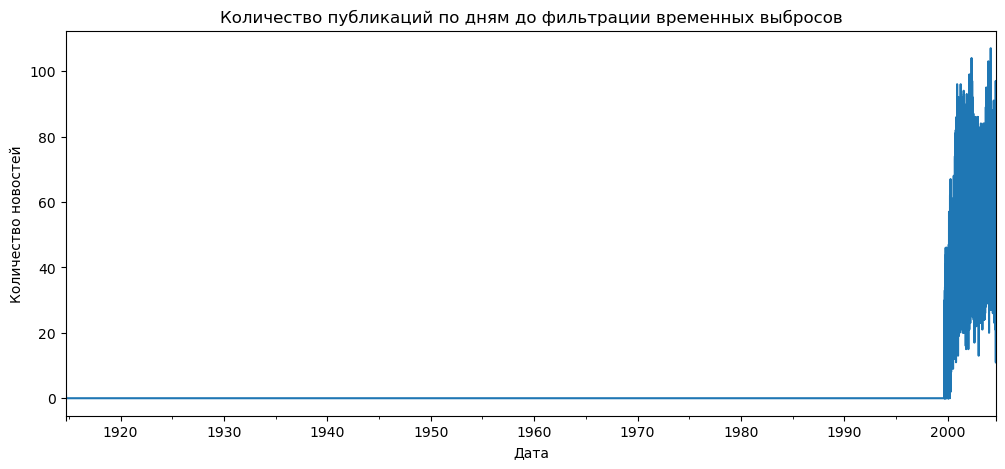

In [13]:
# Диагностический график до отсечения выбросов по времени.
# Если в датах есть очень ранние записи, график может быть визуально сжат.
daily_counts_raw = clean_df.set_index("published_at").resample("D").size()

plt.figure(figsize=(12, 5))
daily_counts_raw.plot()
plt.title("Количество публикаций по дням до фильтрации временных выбросов")
plt.xlabel("Дата")
plt.ylabel("Количество новостей")
plt.show()


In [14]:
print("Распределение дат по квантилям")
date_quantiles = clean_df["published_at"].quantile([
    0.00005,
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
])
print(date_quantiles)

print("\nРаспределение по годам")
year_counts = clean_df["published_at"].dt.year.value_counts().sort_index()
print(year_counts.head(30))

print("\nСамые ранние записи")
clean_df[["published_at", "title", "topic", "url"]].sort_values("published_at").head(20)


Распределение дат по квантилям
0.00005   1998-02-10 17:44:09.599999
0.00010   1999-08-31 00:00:00.000000
0.00050   1999-09-02 00:00:00.000000
0.00100   1999-09-06 00:00:00.000000
0.00500   1999-09-27 00:00:00.000000
0.01000   1999-10-19 00:00:00.000000
Name: published_at, dtype: datetime64[us]

Распределение по годам
published_at
1914        5
1999     3077
2000    16168
2001    21969
2002    22173
2003    21554
2004    14690
Name: count, dtype: int64

Самые ранние записи


,published_at,title,topic,url
0,1914-09-16,1914. Русские войска вступили в пределы Венгрии,Библиотека,https://lenta.ru/news/1914/09/16/hungarnn/
1,1914-09-16,1914. Празднование столетия М.Ю. Лермонтова отложено,Библиотека,https://lenta.ru/news/1914/09/16/lermontov/
2,1914-09-17,1914. Das ist Nesteroff!,Библиотека,https://lenta.ru/news/1914/09/17/nesteroff/
3,1914-09-17,1914. Бульдог-гонец под Льежем,Библиотека,https://lenta.ru/news/1914/09/17/bulldogn/
4,1914-09-18,1914. Под Люблином пойман швабский зверь,Библиотека,https://lenta.ru/news/1914/09/18/zver/
21,1999-08-31,Леворадикалы создают предвыборный блок,Россия,https://lenta.ru/news/1999/08/31/polit_blok/
20,1999-08-31,Референдум по вопросу о самоопределении Восточного Тимора прошел успешно,Мир,https://lenta.ru/news/1999/08/31/timor/
19,1999-08-31,Литва засудила участников переворота 91 года,Мир,https://lenta.ru/news/1999/08/31/litva/
18,1999-08-31,Киргизия ведет бои на границах с Таджикистаном и Узбекистаном,Мир,https://lenta.ru/news/1999/08/31/kirgizia/
17,1999-08-31,Российские национал-большевики убирают территорию Севастополя,Мир,https://lenta.ru/news/1999/08/31/limonov/


0.100% квантиль по дате: 1999-09-06 00:00:00
Количество записей раньше cutoff: 81
Доля записей раньше cutoff: 0.0813%


,published_at,title,topic,url
0,1914-09-16,1914. Русские войска вступили в пределы Венгрии,Библиотека,https://lenta.ru/news/1914/09/16/hungarnn/
1,1914-09-16,1914. Празднование столетия М.Ю. Лермонтова отложено,Библиотека,https://lenta.ru/news/1914/09/16/lermontov/
2,1914-09-17,1914. Das ist Nesteroff!,Библиотека,https://lenta.ru/news/1914/09/17/nesteroff/
3,1914-09-17,1914. Бульдог-гонец под Льежем,Библиотека,https://lenta.ru/news/1914/09/17/bulldogn/
4,1914-09-18,1914. Под Люблином пойман швабский зверь,Библиотека,https://lenta.ru/news/1914/09/18/zver/
21,1999-08-31,Леворадикалы создают предвыборный блок,Россия,https://lenta.ru/news/1999/08/31/polit_blok/
20,1999-08-31,Референдум по вопросу о самоопределении Восточного Тимора прошел успешно,Мир,https://lenta.ru/news/1999/08/31/timor/
19,1999-08-31,Литва засудила участников переворота 91 года,Мир,https://lenta.ru/news/1999/08/31/litva/
18,1999-08-31,Киргизия ведет бои на границах с Таджикистаном и Узбекистаном,Мир,https://lenta.ru/news/1999/08/31/kirgizia/
17,1999-08-31,Российские национал-большевики убирают территорию Севастополя,Мир,https://lenta.ru/news/1999/08/31/limonov/


Удалено записей раньше 1999-09-06 00:00:00: 81
Осталось записей: 99555
Минимальная дата после фильтрации: 1999-09-06 00:00:00
Максимальная дата после фильтрации: 2004-08-31 00:00:00


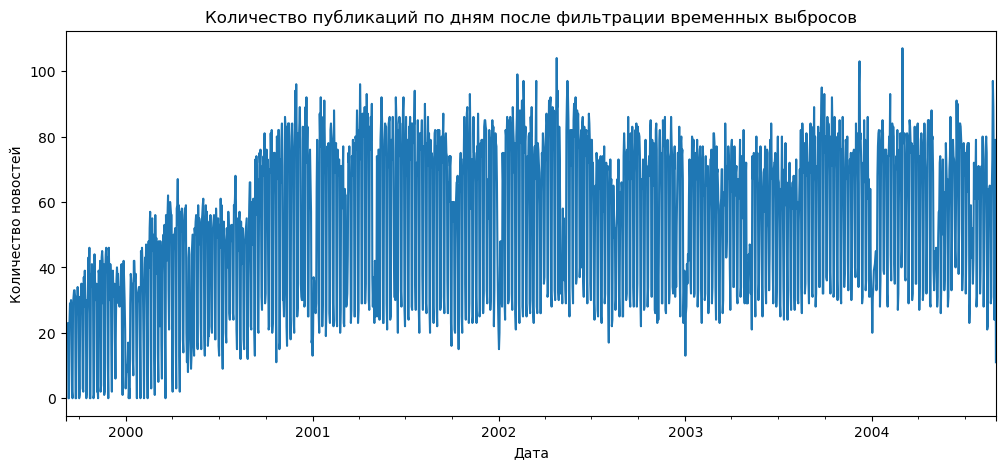

In [15]:
# Отсекаем нижний хвост распределения дат.
# Выбран 0.1% квантиль: это достаточно консервативно и удаляет только явные ранние выбросы.
DATE_OUTLIER_QUANTILE = 0.001

date_cutoff = clean_df["published_at"].quantile(DATE_OUTLIER_QUANTILE)

print(f"{DATE_OUTLIER_QUANTILE:.3%} квантиль по дате:", date_cutoff)

date_outliers_mask = clean_df["published_at"] < date_cutoff

print("Количество записей раньше cutoff:", date_outliers_mask.sum())
print("Доля записей раньше cutoff:", f"{date_outliers_mask.mean():.4%}")

oldest_rows = clean_df.loc[
    date_outliers_mask,
    ["published_at", "title", "topic", "url"]
].sort_values("published_at").head(20)

display(oldest_rows)

before_rows = len(clean_df)

clean_df = clean_df[clean_df["published_at"] >= date_cutoff].copy()
clean_df = clean_df.sort_values("published_at").reset_index(drop=True)
clean_df["news_id"] = np.arange(len(clean_df))

after_rows = len(clean_df)

print(f"Удалено записей раньше {date_cutoff}: {before_rows - after_rows}")
print(f"Осталось записей: {after_rows}")
print("Минимальная дата после фильтрации:", clean_df["published_at"].min())
print("Максимальная дата после фильтрации:", clean_df["published_at"].max())

# Контрольный график после фильтрации.
daily_counts_filtered = clean_df.set_index("published_at").resample("D").size()

plt.figure(figsize=(12, 5))
daily_counts_filtered.plot()
plt.title("Количество публикаций по дням после фильтрации временных выбросов")
plt.xlabel("Дата")
plt.ylabel("Количество новостей")
plt.show()


## 7. EDA - анализ после очистки

### 7.1 Длины текстов и заголовков

Слишком короткие тексты могут не содержать достаточного контекста, а слишком длинные будут обрезаться transformer-моделью.

In [16]:
clean_df[["text_length", "text_num_words", "title_length", "title_num_words", "model_num_words"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,text_length,text_num_words,title_length,title_num_words,model_num_words
count,99555.000000,99555.000000,99555.000000,99555.000000,99555.000000
mean,1190.548611,159.214364,56.260640,7.613249,166.828858
std,609.105282,83.077031,13.120919,1.940902,83.335643
min,99.000000,12.000000,15.000000,2.000000,20.000000
1%,363.540000,48.000000,29.000000,4.000000,55.000000
5%,496.000000,65.000000,36.000000,5.000000,73.000000
25%,783.000000,104.000000,47.000000,6.000000,112.000000
50%,1072.000000,143.000000,56.000000,7.000000,151.000000
75%,1460.000000,195.000000,65.000000,9.000000,203.000000
95%,2298.000000,308.000000,79.000000,11.000000,316.000000


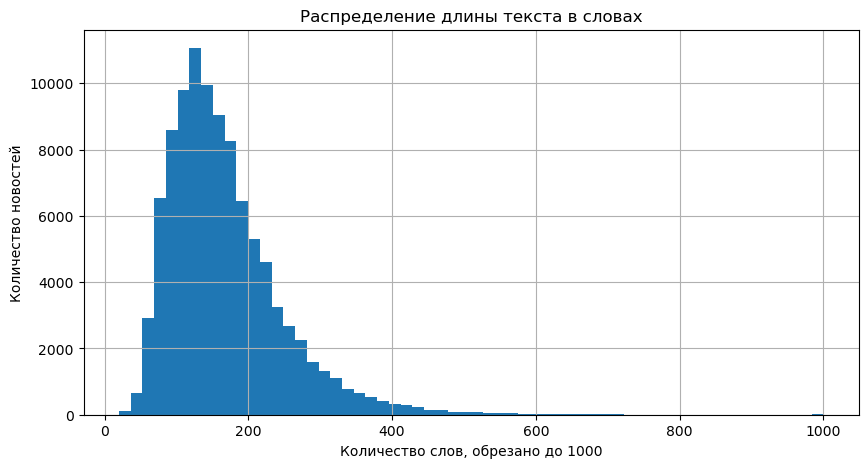

In [17]:
plt.figure(figsize=(10, 5))
clip_text_display_at = 1000
clean_df["model_num_words"].clip(upper=clip_text_display_at).hist(bins=60)
plt.title("Распределение длины текста в словах")
plt.xlabel(f"Количество слов, обрезано до {clip_text_display_at}")
plt.ylabel("Количество новостей")
plt.show()

Вывод: тексты достаточно длинные, поэтому нужно проверить, насколько выбранная embedding-модель будет обрезать вход.

Здесь важно не просто «подкрутить» `max_seq_length` у модели, а выбрать такую базовую модель, чей рабочий контекст соответствует длине наших новостных текстов. Поэтому сначала используем `paraphrase-multilingual-mpnet-base-v2` как диагностическую точку: она показывает проблему короткого контекста. После этого выбираем новую базовую embedding-модель для дальнейшей работы.


In [18]:
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
from transformers.utils import logging as hf_logging


warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

# Старая кандидатная модель из первого варианта ноутбука.
# Она подходит для коротких предложений/абзацев, но для полных новостных текстов её контекст слишком мал.
DIAGNOSTIC_EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

diagnostic_model = SentenceTransformer(DIAGNOSTIC_EMBEDDING_MODEL_NAME)
diagnostic_max_seq_length = diagnostic_model.max_seq_length

print("Диагностическая модель:", DIAGNOSTIC_EMBEDDING_MODEL_NAME)
print("max_seq_length:", diagnostic_max_seq_length)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Диагностическая модель: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
max_seq_length: 128


In [19]:
def compute_token_lengths(
    texts: pd.Series,
    model: SentenceTransformer,
    *,
    batch_log_name: str = "model",
) -> pd.Series:
    """Считает длину входа в токенах без truncation для tokenizer выбранной модели."""
    token_lengths = []

    for text in tqdm(texts.fillna("").astype(str), desc=f"Token lengths: {batch_log_name}"):
        tokens = model.tokenizer(
            text,
            truncation=False,
            add_special_tokens=True,
            verbose=False,
        )
        token_lengths.append(len(tokens["input_ids"]))

    return pd.Series(token_lengths, index=texts.index)


def print_token_coverage_report(token_lengths: pd.Series, max_seq_length: int, model_name: str) -> None:
    """Печатает покрытие текстов контекстом модели."""
    too_long = (token_lengths > max_seq_length)
    truncated_share = too_long.mean()
    too_long_count = int(too_long.sum())

    print("Модель:", model_name)
    print("max_seq_length:", max_seq_length)
    print(f"Текстов длиннее max_seq_length: {too_long_count}")
    print("Доля текстов длиннее max_seq_length:", f"{truncated_share:.4%}")
    print("\nРаспределение длин в токенах:")
    print(token_lengths.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


In [20]:
clean_df["token_length_mpnet"] = compute_token_lengths(
    clean_df["model_text"],
    diagnostic_model,
    batch_log_name="mpnet diagnostic",
)

print_token_coverage_report(
    clean_df["token_length_mpnet"],
    diagnostic_max_seq_length,
    DIAGNOSTIC_EMBEDDING_MODEL_NAME,
)


Token lengths: mpnet diagnostic:   0%|          | 0/99555 [00:00<?, ?it/s]

Модель: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
max_seq_length: 128
Текстов длиннее max_seq_length: 96423
Доля текстов длиннее max_seq_length: 96.8540%

Распределение длин в токенах:
count    99555.000000
mean       310.594676
std        150.877811
min         40.000000
25%        210.000000
50%        281.000000
75%        376.000000
90%        492.000000
95%        581.000000
99%        801.000000
max      13148.000000
Name: token_length_mpnet, dtype: float64


Вывод по диагностической модели:

`paraphrase-multilingual-mpnet-base-v2` не стоит использовать как рабочую базовую модель для полного текста новости: значимая часть публикаций длиннее её рабочего контекста, а искусственное увеличение `model.max_seq_length` не делает модель обученной на таких длинных входах.

Поэтому для дальнейшего baseline выбираем новую модель, которая изначально рассчитана на более длинный multilingual input.


In [21]:
# Новая рабочая baseline-модель для дальнейших этапов проекта.
# BAAI/bge-m3 выбрана как multilingual embedding-модель с поддержкой длинного контекста.
from sentence_transformers import SentenceTransformer

BASE_EMBEDDING_MODEL_NAME = "BAAI/bge-m3"

base_embedding_model = SentenceTransformer(
    BASE_EMBEDDING_MODEL_NAME,
    model_kwargs={"use_safetensors": True},
)

base_max_seq_length = base_embedding_model.max_seq_length

print("Новая baseline embedding-модель:", BASE_EMBEDDING_MODEL_NAME)
print("Рабочий max_seq_length для MVP:", base_max_seq_length)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Новая baseline embedding-модель: BAAI/bge-m3
Рабочий max_seq_length для MVP: 8192


In [22]:
clean_df["token_length_bge_m3"] = compute_token_lengths(
    clean_df["model_text"],
    base_embedding_model,
    batch_log_name="bge-m3 baseline",
)


Token lengths: bge-m3 baseline:   0%|          | 0/99555 [00:00<?, ?it/s]

In [23]:
print_token_coverage_report(
    clean_df["token_length_bge_m3"],
    base_max_seq_length,
    BASE_EMBEDDING_MODEL_NAME,
)

too_long_mask = clean_df["token_length_bge_m3"] > base_max_seq_length
clean_df.loc[
    too_long_mask,
    ["news_id", "published_at", "topic", "title", "text_length", "text_num_words", "token_length_bge_m3"]
].sort_values("token_length_bge_m3", ascending=False).head(20)

Модель: BAAI/bge-m3
max_seq_length: 8192
Текстов длиннее max_seq_length: 1
Доля текстов длиннее max_seq_length: 0.0010%

Распределение длин в токенах:
count    99555.000000
mean       310.594676
std        150.877811
min         40.000000
25%        210.000000
50%        281.000000
75%        376.000000
90%        492.000000
95%        581.000000
99%        801.000000
max      13148.000000
Name: token_length_bge_m3, dtype: float64


,news_id,published_at,topic,title,text_length,text_num_words,token_length_bge_m3
84093,84093,2003-12-18,Россия,Пресс-конференция Владимира Путина. Интернет-трансляция,55387,8092,13148


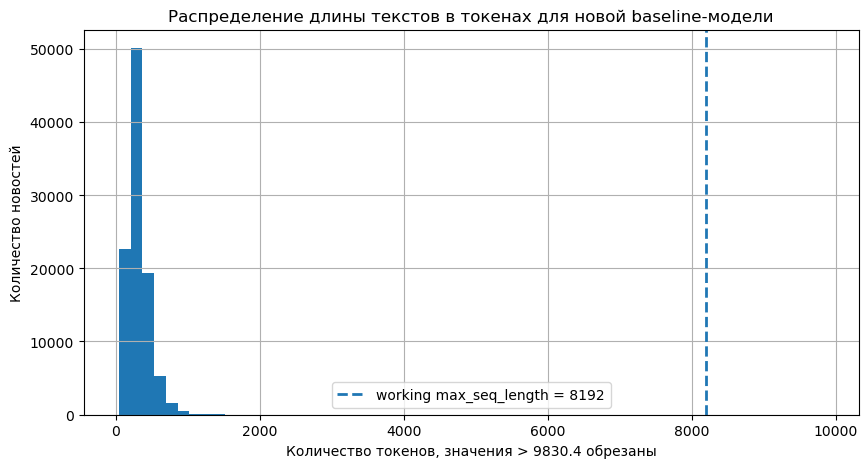

In [24]:
plt.figure(figsize=(10, 5))

clip_at = base_max_seq_length * 1.2

clean_df["token_length_bge_m3"].clip(upper=clip_at).hist(bins=60)

plt.axvline(
    base_max_seq_length,
    linestyle="--",
    linewidth=2,
    label=f"working max_seq_length = {base_max_seq_length}"
)

plt.title("Распределение длины текстов в токенах для новой baseline-модели")
plt.xlabel(f"Количество токенов, значения > {clip_at} обрезаны")
plt.ylabel("Количество новостей")
plt.legend()
plt.show()


In [25]:
long_text_outlier_mask = clean_df["token_length_bge_m3"] > base_embedding_model.max_seq_length

long_text_outliers = clean_df.loc[
    long_text_outlier_mask,
    ["news_id", "published_at", "topic", "title", "text_length", "text_num_words", "token_length_bge_m3"]
].copy()

long_text_outliers

,news_id,published_at,topic,title,text_length,text_num_words,token_length_bge_m3
84093,84093,2003-12-18,Россия,Пресс-конференция Владимира Путина. Интернет-трансляция,55387,8092,13148


In [26]:
EMBEDDING_BASELINE_CONFIG = {
    "diagnostic_model_name": DIAGNOSTIC_EMBEDDING_MODEL_NAME,
    "diagnostic_model_max_seq_length": int(diagnostic_max_seq_length),
    "base_embedding_model_name": BASE_EMBEDDING_MODEL_NAME,    
    "base_embedding_working_max_seq_length": int(base_max_seq_length),
    "long_text_strategy": "При превышении лимита токенов, необходимо либо удалять такие новости из агрегации, либо решать вопрос с их укорачиванием/разрешанием и агрегацией векторов",
}

EMBEDDING_BASELINE_CONFIG_PATH = PREPARED_DIR / "embedding_baseline_config.json"
with open(EMBEDDING_BASELINE_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(EMBEDDING_BASELINE_CONFIG, f, ensure_ascii=False, indent=2)

EMBEDDING_BASELINE_CONFIG


{'diagnostic_model_name': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
 'diagnostic_model_max_seq_length': 128,
 'base_embedding_model_name': 'BAAI/bge-m3',
 'base_embedding_working_max_seq_length': 8192,
 'long_text_strategy': 'При превышении лимита токенов, необходимо либо удалять такие новости из агрегации, либо решать вопрос с их укорачиванием/разрешанием и агрегацией векторов'}

Вывод:

Изначальная `paraphrase-multilingual-mpnet-base-v2` оставлена только как диагностический пример неудачного выбора для полного текста новости. Увеличивать ей `max_seq_length` вручную не будем: это технически уменьшает число обрезанных входов, но не решает проблему качества представлений и факт того, что модель обучалась на коротких текстах и выдаст не очень хорошую картину на длинных.

В качестве новой базовой embedding-модели для дальнейших этапов выбираем `BAAI/bge-m3`.После перехода на `BAAI/bge-m3` почти все тексты корпуса помещаются в нативный лимит модели 8192 токена. 
В датасете найден только один текст длиннее лимита — это не обычная новостная заметка, а длинная интернет-трансляция пресс-конференции. 
Для дальнейшего baseline такой объект можно считать выбросом по длине и либо удалить из обучающей/оценочной выборки, либо обрабатывать отдельно через chunking. 

В отличие от paraphrase-multilingual-mpnet-base-v2, у которой значимая часть корпуса превышала лимит 128 токенов, BAAI/bge-m3 покрывает практически весь корпус без ручного увеличения max_length. Поэтому дальше в проекте используем её как базовую embedding-модель.


Эта конфигурация должна использоваться дальше как baseline embedding config, в том числе при построении baseline-модели и будущего сервиса.


### 7.2 Распределение по темам

Поле `topic` в Lenta.ru — это широкая рубрика. Для проекта оно не является финальным сюжетным кластером: рубрика слишком крупная. 
Но она может быть полезна как верхний уровень навигации и как способ ограничить область поиска кандидатов.

In [27]:
topic_counts = clean_df["topic"].value_counts()
topic_counts.head(30)

topic
Россия               38293
Мир                  29457
Экономика             9781
Спорт                 6667
Культура              6296
Интернет и СМИ        5922
Из жизни              2885
Наука и техника        252
Силовые структуры        1
Бывший СССР              1
Name: count, dtype: int64

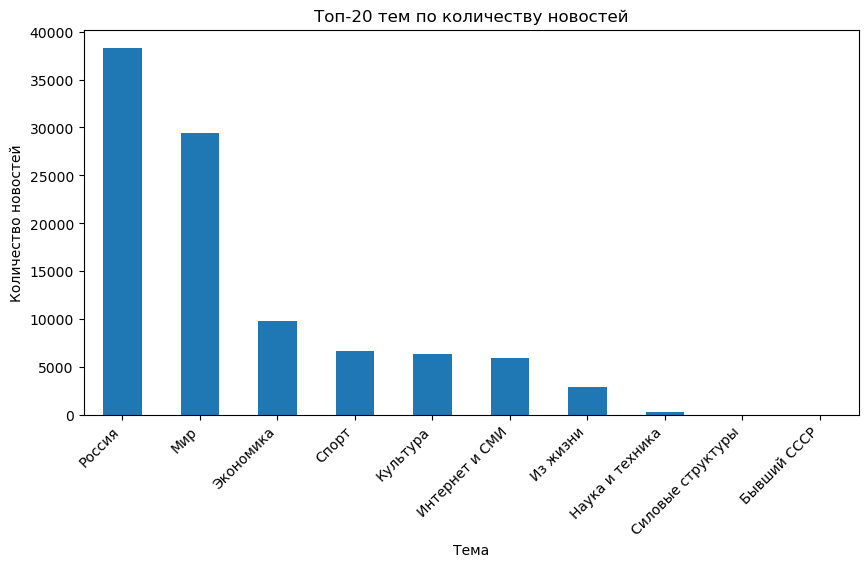

In [28]:
plt.figure(figsize=(10, 5))
topic_counts.head(20).plot(kind="bar")
plt.title("Топ-20 тем по количеству новостей")
plt.xlabel("Тема")
plt.ylabel("Количество новостей")
plt.xticks(rotation=45, ha="right")
plt.show()

### 7.3 Распределение по времени

Так как будущая система работает с новостным потоком, временное распределение критично для выбора окна времени для фильтрации и стратегии валидации.

In [29]:
print("Минимальная дата:", clean_df["published_at"].min())
print("Максимальная дата:", clean_df["published_at"].max())

Минимальная дата: 1999-09-06 00:00:00
Максимальная дата: 2004-08-31 00:00:00


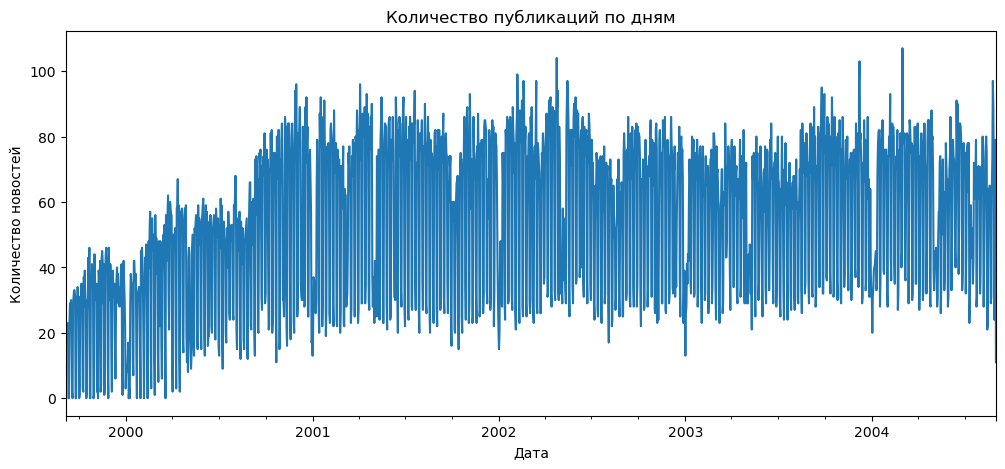

In [30]:
daily_counts = clean_df.set_index("published_at").resample("D").size()

plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title("Количество публикаций по дням")
plt.xlabel("Дата")
plt.ylabel("Количество новостей")
plt.show()

Вывод:
Видно, что до 2001 количество новостей меньше, чем после. Поэтому для обучающего golden set будем брать временные отрезки после 2001 года.

### 7.4 Корреляции признаков

Это текстовая задача, поэтому классические линейные корреляции на сырых данных имеют ограниченную ценность. Тем не менее полезно проверить технические числовые признаки: длину текста и заголовка.

In [31]:
numeric_cols = ["text_length", "text_num_words", "title_length", "title_num_words"]
clean_df[numeric_cols].corr()

,text_length,text_num_words,title_length,title_num_words
text_length,1.000000,0.992267,0.141126,0.112995
text_num_words,0.992267,1.000000,0.131779,0.121774
title_length,0.141126,0.131779,1.000000,0.805534
title_num_words,0.112995,0.121774,0.805534,1.000000


Вывод: сильная корреляция между `text_length` и `text_num_words` есть, но не является проблемой. Эти признаки нужны в первую очередь для контроля качества данных, а не как основные признаки модели.

## 8. Нужно ли масштабирование

Для текущей постановки классическое масштабирование признаков не требуется.

Причины:

1. Основной вход модели — текст, а не числовая таблица.
2. Текст будет преобразован в embedding-векторы с помощью sentence-transformer.
3. Для cosine similarity важна не стандартизация через `StandardScaler`, а L2-нормализация embedding-векторов.
4. Для rule-based decision layer масштабирование similarity-признаков не требуется, так как они уже находятся в сопоставимом диапазоне.

Если в дальнейшем поверх similarity-признаков будет обучаться отдельный классификатор, необходимость масштабирования будет зависеть от алгоритма. Например, для Logistic Regression масштабирование может быть полезно, а для деревьев решений — обычно нет.

## 9. Формирование очищенного датасета

На этом этапе сохраняем очищенные данные. Это ещё не финальная novelty-выборка, а базовый датасет новостей, из которого дальше строятся эмбеддинги, кластеры и кандидаты на ручную разметку.

In [32]:
news_output_cols = [
    "news_id",
    "url",
    "title",
    "text",
    "topic",
    "tags",
    "published_at",
    "text_length",
    "text_num_words",
    "title_length",
    "title_num_words",
    "model_text",
    "model_length",
    "model_num_words"
]

clean_news_path = PREPARED_DIR / "lenta_clean_news.csv"
clean_df[news_output_cols].to_csv(clean_news_path, index=False)
clean_news_path

WindowsPath('E:/ML/Projects/Git/news-flow-analysis/data/prepared/lenta_clean_news.csv')

## 10. Формирование `golden_candidate_set`

В Lenta.ru нет готовой разметки сюжетов и существенной новизны. Поэтому сначала фиксируем небольшой воспроизводимый срез новостного потока — `golden_candidate_set`.

Важно: `golden_candidate_set` ещё не является golden set. Это только набор новостей, из которого на следующих шагах будут подготовлены шаблоны для ручной и LLM-разметки.

Логика дальнейшей работы:

```text
golden_candidate_set
↓
preliminary clustering
↓
golden_set_human_template  # небольшая часть для ручной разметки
golden_set_llm_template    # те же строки для LLM-разметки
silver_set_llm_template    # весь scope для будущей LLM-разметки
```

Финальными размеченными наборами станут только заполненные версии этих шаблонов:

- `golden_set_human` — маленький human-labeled benchmark;
- `golden_set_llm` — LLM-разметка тех же строк для сравнения с человеком;
- `silver_set_llm` — LLM-разметка всего `golden_candidate_set`.


In [33]:
# Настройки golden_candidate_set.
# Срез выбран как непрерывный фрагмент новостного потока из событийных рубрик.

GOLDEN_SLICE_ID = "lenta_2004_03_01_2004_04_07_russia_world_economy"

GOLDEN_START_DATE = pd.Timestamp("2004-03-01")
GOLDEN_END_DATE = pd.Timestamp("2004-04-08")  # exclusive

GOLDEN_TOPICS = [
    "Россия",
    "Мир",
    "Экономика",
]

GOLDEN_CANDIDATE_SET_PATH = PREPARED_DIR / "lenta_golden_candidate_set.csv"
GOLDEN_CANDIDATE_SET_MANIFEST_PATH = PREPARED_DIR / "lenta_golden_candidate_set_manifest.json"


In [34]:
import json

golden_candidate_set = clean_df[
    (clean_df["published_at"] >= GOLDEN_START_DATE)
    & (clean_df["published_at"] < GOLDEN_END_DATE)
    & (clean_df["topic"].isin(GOLDEN_TOPICS))
].copy()

golden_candidate_set = golden_candidate_set.sort_values(
    ["published_at", "news_id"]
).reset_index(drop=True)

golden_candidate_set["golden_slice_id"] = GOLDEN_SLICE_ID

golden_candidate_set.to_csv(GOLDEN_CANDIDATE_SET_PATH, index=False)

manifest = {
    "golden_slice_id": GOLDEN_SLICE_ID,
    "source_dataset": str(clean_news_path),
    "start_date": str(GOLDEN_START_DATE.date()),
    "end_date_exclusive": str(GOLDEN_END_DATE.date()),
    "topics": GOLDEN_TOPICS,
    "num_rows": int(len(golden_candidate_set)),
    "min_published_at": str(golden_candidate_set["published_at"].min()),
    "max_published_at": str(golden_candidate_set["published_at"].max()),
    "purpose": (
        "Fixed news subset for preparing story-level human and LLM novelty annotation. "
        "This file is not a final golden set and does not contain target labels."
    ),
}

with open(GOLDEN_CANDIDATE_SET_MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("golden_candidate_set:", golden_candidate_set.shape)
print("period:", golden_candidate_set["published_at"].min(), "—", golden_candidate_set["published_at"].max())
print("topics:")
print(golden_candidate_set["topic"].value_counts())
print("\nsaved:", GOLDEN_CANDIDATE_SET_PATH)
print("manifest:", GOLDEN_CANDIDATE_SET_MANIFEST_PATH)


golden_candidate_set: (2036, 17)
period: 2004-03-01 00:00:00 — 2004-04-07 00:00:00
topics:
topic
Россия       984
Мир          868
Экономика    184
Name: count, dtype: int64

saved: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_candidate_set.csv
manifest: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_candidate_set_manifest.json


count    38.000000
mean     53.578947
std      17.185210
min      19.000000
25%      50.000000
50%      62.000000
75%      64.000000
max      74.000000
dtype: float64


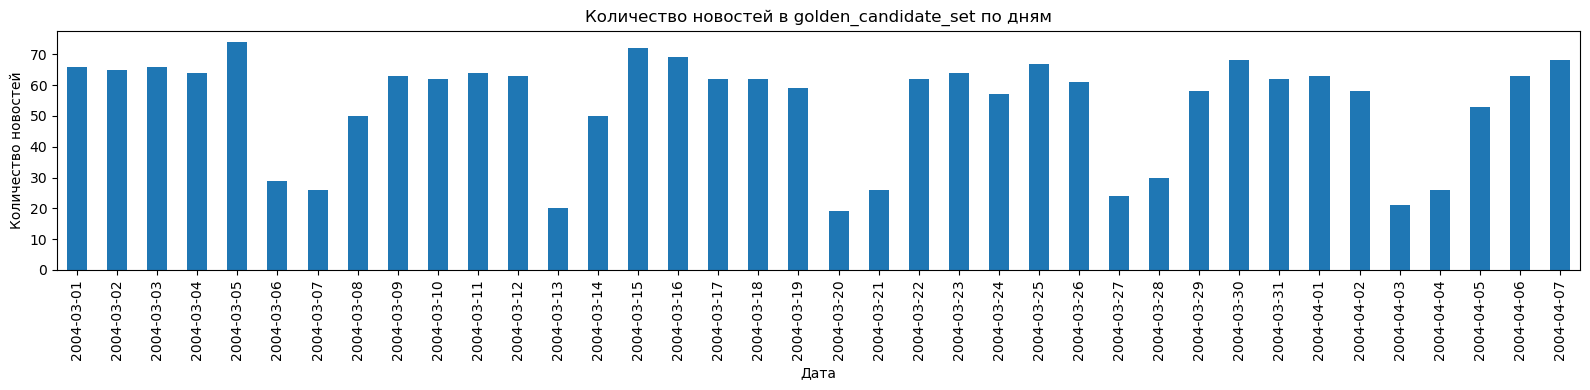

In [35]:
daily_counts = golden_candidate_set.groupby(
    golden_candidate_set["published_at"].dt.date
).size()

print(daily_counts.describe())

daily_counts.plot(
    kind="bar",
    figsize=(16, 4),
    title="Количество новостей в golden_candidate_set по дням",
)
plt.xlabel("Дата")
plt.ylabel("Количество новостей")
plt.tight_layout()


## 11. Предварительная кластеризация `golden_candidate_set`

На этом шаге добавляем к `golden_candidate_set` поле `preliminary_cluster_id`.

Это не эталонная разметка сюжетов. Автоматическая кластеризация используется только как удобная заготовка для человека и LLM, чтобы они работали не с хаотичным списком новостей, а с предварительными сюжетными группами.

Идея baseline-кластеризации простая:

1. строим TF-IDF-векторы по `model_text`;
2. внутри каждой рубрики `topic` считаем cosine similarity;
3. соединяем новости в один preliminary cluster, если они достаточно похожи и опубликованы в пределах заданного временного окна;
4. компоненты связности такого графа считаем предварительными сюжетами.

Такой подход специально оставлен простым и интерпретируемым. В дальнейшем его можно заменить на sentence-transformer embeddings и более аккуратную кластеризацию.


In [36]:
# Настройки предварительной кластеризации.

CLUSTER_TEXT_PREFIX_CHARS = 2_000
CLUSTER_TFIDF_MAX_FEATURES = 50_000
CLUSTER_SIMILARITY_THRESHOLD = 0.42
CLUSTER_TIME_WINDOW_DAYS = 14

CLUSTERED_CANDIDATE_SET_PATH = PREPARED_DIR / "lenta_golden_candidate_set_clustered.csv"


In [37]:
def _find(parent, x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def _union(parent, rank, a, b):
    root_a = _find(parent, a)
    root_b = _find(parent, b)

    if root_a == root_b:
        return

    if rank[root_a] < rank[root_b]:
        parent[root_a] = root_b
    elif rank[root_a] > rank[root_b]:
        parent[root_b] = root_a
    else:
        parent[root_b] = root_a
        rank[root_a] += 1


def assign_preliminary_clusters(
    df: pd.DataFrame,
    text_col: str = "model_text",
    topic_col: str = "topic",
    time_col: str = "published_at",
    similarity_threshold: float = 0.42,
    time_window_days: int = 14,
) -> pd.DataFrame:
    """
    Assigns preliminary story clusters using TF-IDF similarity and temporal filtering.

    The resulting preliminary_cluster_id is an annotation aid, not a gold label.
    """
    work = df.copy().reset_index(drop=True)

    work["cluster_text"] = work[text_col].fillna("").str.slice(0, CLUSTER_TEXT_PREFIX_CHARS)

    vectorizer = TfidfVectorizer(
        max_features=CLUSTER_TFIDF_MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )
    X = vectorizer.fit_transform(work["cluster_text"])

    raw_cluster_ids = pd.Series(index=work.index, dtype="object")
    cluster_counter = 0

    for topic, topic_indices in work.groupby(topic_col).groups.items():
        topic_indices = np.array(sorted(topic_indices))
        n = len(topic_indices)

        if n == 0:
            continue

        parent = list(range(n))
        rank = [0] * n

        X_topic = X[topic_indices]
        sim_matrix = cosine_similarity(X_topic)

        published_at = work.loc[topic_indices, time_col].to_numpy(dtype="datetime64[ns]")
        time_delta_hours = np.abs(
            (published_at[:, None] - published_at[None, :]).astype("timedelta64[h]").astype(float)
        )

        edge_mask = (
            (sim_matrix >= similarity_threshold)
            & (time_delta_hours <= time_window_days * 24)
        )

        # Соединяем только верхний треугольник, чтобы не дублировать операции.
        rows, cols = np.where(np.triu(edge_mask, k=1))
        for a, b in zip(rows, cols):
            _union(parent, rank, int(a), int(b))

        root_to_local_cluster = {}
        for local_idx, global_idx in enumerate(topic_indices):
            root = _find(parent, local_idx)
            if root not in root_to_local_cluster:
                cluster_counter += 1
                root_to_local_cluster[root] = f"prelim_{cluster_counter:04d}"
            raw_cluster_ids.loc[global_idx] = root_to_local_cluster[root]

    work["preliminary_cluster_id"] = raw_cluster_ids

    cluster_summary = (
        work.groupby("preliminary_cluster_id")
        .agg(
            cluster_size=("news_id", "size"),
            cluster_main_topic=(topic_col, lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
            cluster_start_at=(time_col, "min"),
            cluster_end_at=(time_col, "max"),
            cluster_first_title=("title", "first"),
        )
        .reset_index()
        .sort_values(["cluster_start_at", "cluster_main_topic", "preliminary_cluster_id"])
        .reset_index(drop=True)
    )

    # Переупорядочиваем id так, чтобы они шли по времени начала сюжета.
    ordered_ids = {
        old_id: f"prelim_{idx + 1:04d}"
        for idx, old_id in enumerate(cluster_summary["preliminary_cluster_id"])
    }
    work["preliminary_cluster_id"] = work["preliminary_cluster_id"].map(ordered_ids)

    cluster_summary["preliminary_cluster_id"] = cluster_summary["preliminary_cluster_id"].map(ordered_ids)

    work = work.drop(columns=["cluster_text"])

    cluster_features = cluster_summary.drop(columns=["cluster_first_title"])
    work = work.merge(cluster_features, on="preliminary_cluster_id", how="left")

    work = work.sort_values(["preliminary_cluster_id", "published_at", "news_id"]).reset_index(drop=True)
    work["order_in_preliminary_cluster"] = (
        work.groupby("preliminary_cluster_id").cumcount() + 1
    )

    return work


In [38]:
golden_candidate_set_clustered = assign_preliminary_clusters(
    golden_candidate_set,
    similarity_threshold=CLUSTER_SIMILARITY_THRESHOLD,
    time_window_days=CLUSTER_TIME_WINDOW_DAYS,
)

golden_candidate_set_clustered.to_csv(CLUSTERED_CANDIDATE_SET_PATH, index=False)

print("clustered candidate set:", golden_candidate_set_clustered.shape)
print("num preliminary clusters:", golden_candidate_set_clustered["preliminary_cluster_id"].nunique())
print("saved:", CLUSTERED_CANDIDATE_SET_PATH)

golden_candidate_set_clustered[[
    "preliminary_cluster_id",
    "cluster_size",
    "order_in_preliminary_cluster",
    "published_at",
    "topic",
    "title",
]].head(20)


clustered candidate set: (2036, 23)
num preliminary clusters: 1765
saved: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_candidate_set_clustered.csv


,preliminary_cluster_id,cluster_size,order_in_preliminary_cluster,published_at,topic,title
0,prelim_0001,1,1,2004-03-01,Мир,Жертвы ядерных испытаний на Бикини в день 50-летия взрыва требуют компенсаций
1,prelim_0002,2,1,2004-03-01,Мир,Задержанного в Швейцарии Виталия Калоева поместили в психиатрическую клинику
2,prelim_0002,2,2,2004-03-02,Мир,Швейцария разрешила российским дипломатам встретиться с Виталием Калоевым
3,prelim_0003,2,1,2004-03-01,Мир,Белоруссия признала катарских борцов своими
4,prelim_0003,2,2,2004-03-01,Мир,Задержанные в Москве катарские борцы оказались белоруссами
5,prelim_0004,5,1,2004-03-01,Мир,Изгнанный президент Гаити прилетел в Центрально-Африканскую Республику
6,prelim_0004,5,2,2004-03-01,Мир,На Гаити высадились французские миротворцы
7,prelim_0004,5,3,2004-03-02,Мир,"Жан-Бертран Аристид: ""США вынудили меня бежать из страны"""
8,prelim_0004,5,4,2004-03-04,Мир,На родине культа вуду введено чрезвычайное положение
9,prelim_0004,5,5,2004-03-04,Мир,За бывшего президента Гаити вступились соседние страны


In [39]:
cluster_stats = (
    golden_candidate_set_clustered
    .groupby("preliminary_cluster_id")
    .agg(
        cluster_size=("news_id", "size"),
        main_topic=("topic", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        start_at=("published_at", "min"),
        end_at=("published_at", "max"),
        first_title=("title", "first"),
    )
    .reset_index()
)

print(cluster_stats["cluster_size"].describe())
print("\nРаспределение размеров preliminary clusters:")
print(cluster_stats["cluster_size"].value_counts().sort_index().head(30))

cluster_stats.sort_values("cluster_size", ascending=False).head(20)


count    1765.000000
mean        1.153541
std         0.573108
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         9.000000
Name: cluster_size, dtype: float64

Распределение размеров preliminary clusters:
cluster_size
1    1584
2     133
3      26
4      13
5       4
6       3
9       2
Name: count, dtype: int64


,preliminary_cluster_id,cluster_size,main_topic,start_at,end_at,first_title
612,prelim_0613,9,Россия,2004-03-13,2004-03-14,Выборы президента Российской Федерации начались
642,prelim_0643,9,Россия,2004-03-14,2004-03-15,"Подсчитано 16 процентов: Путин, Харитонов, Глазьев"
1687,prelim_1688,6,Россия,2004-04-06,2004-04-07,Кадыров готов гарантировать Масхадову безопасность
1391,prelim_1392,6,Россия,2004-03-30,2004-04-07,"Ходорковский признал ""Кризис"" своим на 100 процентов"
1162,prelim_1163,6,Мир,2004-03-25,2004-04-04,Ричард Кларк: в терактах 11 сентября виноват Буш
628,prelim_0629,5,Россия,2004-03-14,2004-03-14,На Дальнем Востоке выборы завершились. Явка на Сахалине едва превысила 50 процентов
3,prelim_0004,5,Мир,2004-03-01,2004-03-04,Изгнанный президент Гаити прилетел в Центрально-Африканскую Республику
306,prelim_0307,5,Россия,2004-03-06,2004-03-10,Спасенных российских полярников доставили на Шпицберген
1336,prelim_1337,5,Россия,2004-03-29,2004-03-30,Узбекские власти официально сообщили о пяти взрывах в стране
37,prelim_0038,4,Россия,2004-03-01,2004-03-03,"Заместитель генпрокурора России подтвердил, что Гелаев убит"


## 12. Подготовка шаблонов для human/LLM-разметки и будущего `silver_set_llm`

Теперь выбираем небольшую часть предварительных сюжетных групп для ручной разметки.
Будет "большой" Silver set для разметки с помощью LLM, и Golden set для ручной разметки (и также для сранвния будет делаться аналог и с помощью LLM).

Принцип отбора:

- берём целые preliminary clusters, а не случайные отдельные новости;
- избегаем одиночных кластеров, потому что внутри них нельзя оценивать novelty-динамику;
- избегаем слишком больших кластеров, потому что их тяжело размечать вручную;
- стараемся сохранить разные рубрики и разные размеры сюжетов;
- целевой объём — примерно 100–200 новостей для golden.

На выходе создаются три файла:

1. `lenta_golden_set_human_template.csv` — шаблон для ручной разметки выбранного subset;
2. `lenta_golden_set_llm_template.csv` — те же строки для независимой LLM-разметки;
3. `lenta_silver_set_llm_template.csv` — весь silver set для будущей LLM-разметки.

Все annotation-файлы сохраняются в едином упрощённом формате:

```text
news_id
published_at
topic
title
text
cluster_id
novelty_label
comment
needs_review
```

`cluster_id` в шаблоне изначально заполняется значением из `preliminary_cluster_id`, но считается редактируемым полем. Человек, LLM или модель могут подтвердить этот кластер, разделить его или перенести новость в другой финальный сюжет.

Технические поля `preliminary_cluster_id`, `cluster_size`, `order_in_preliminary_cluster`, `model_text` остаются в `lenta_golden_candidate_set_clustered.csv`, но не попадают в annotation-файлы, чтобы не перегружать ручную разметку.

`silver_set_llm_template` ещё не является silver set. Он станет `silver_set_llm` только после заполнения LLM-меток.


In [40]:
# Настройки отбора human subset.

HUMAN_MIN_CLUSTER_SIZE = 3
HUMAN_MAX_CLUSTER_SIZE = 12
HUMAN_TARGET_MIN_NEWS = 120
HUMAN_TARGET_MAX_NEWS = 200

GOLDEN_SET_HUMAN_TEMPLATE_PATH = PREPARED_DIR / "lenta_golden_set_human_template.csv"
GOLDEN_SET_LLM_TEMPLATE_PATH = PREPARED_DIR / "lenta_golden_set_llm_template.csv"
SILVER_SET_LLM_TEMPLATE_PATH = PREPARED_DIR / "lenta_silver_set_llm_template.csv"


In [41]:
def select_clusters_for_human_annotation(
    cluster_stats: pd.DataFrame,
    min_cluster_size: int = 3,
    max_cluster_size: int = 12,
    target_min_news: int = 120,
    target_max_news: int = 200,
) -> list[str]:
    eligible = cluster_stats[
        (cluster_stats["cluster_size"] >= min_cluster_size)
        & (cluster_stats["cluster_size"] <= max_cluster_size)
    ].copy()

    if eligible.empty:
        raise ValueError("No eligible clusters for human annotation. Try changing cluster size thresholds.")

    # Round-robin по темам: сначала первый подходящий кластер каждой темы, потом второй, и т.д.
    # Это даёт более разнообразный subset, чем простой top-N по размеру или дате.
    eligible = eligible.sort_values(["main_topic", "start_at", "cluster_size"])
    eligible["topic_rank"] = eligible.groupby("main_topic").cumcount()
    eligible = eligible.sort_values(["topic_rank", "main_topic", "start_at"])

    selected = []
    total_news = 0

    for _, row in eligible.iterrows():
        cluster_size = int(row["cluster_size"])

        if total_news + cluster_size > target_max_news:
            continue

        selected.append(row["preliminary_cluster_id"])
        total_news += cluster_size

        if total_news >= target_min_news:
            break

    return selected


selected_preliminary_clusters = select_clusters_for_human_annotation(
    cluster_stats=cluster_stats,
    min_cluster_size=HUMAN_MIN_CLUSTER_SIZE,
    max_cluster_size=HUMAN_MAX_CLUSTER_SIZE,
    target_min_news=HUMAN_TARGET_MIN_NEWS,
    target_max_news=HUMAN_TARGET_MAX_NEWS,
)

selected_cluster_stats = cluster_stats[
    cluster_stats["preliminary_cluster_id"].isin(selected_preliminary_clusters)
].copy()

print("selected clusters:", len(selected_preliminary_clusters))
print("selected news:", int(selected_cluster_stats["cluster_size"].sum()))

selected_cluster_stats.sort_values(["main_topic", "start_at", "preliminary_cluster_id"])


selected clusters: 32
selected news: 121


,preliminary_cluster_id,cluster_size,main_topic,start_at,end_at,first_title
3,prelim_0004,5,Мир,2004-03-01,2004-03-04,Изгнанный президент Гаити прилетел в Центрально-Африканскую Республику
80,prelim_0081,3,Мир,2004-03-02,2004-03-08,Opportunity выполнил свою миссию
450,prelim_0451,3,Мир,2004-03-10,2004-03-12,Южнокорейские оппозиционеры дали президенту Ро Му Хену еще один шанс
457,prelim_0458,3,Мир,2004-03-10,2004-03-15,Палестинцы обвиняют США в убийстве Абу Аббаса
551,prelim_0552,3,Мир,2004-03-12,2004-04-05,США беззащитны перед северокорейскими ракетами
823,prelim_0824,4,Мир,2004-03-18,2004-03-28,NASA готовит к запуску гиперзвуковой беспилотный самолет
990,prelim_0991,3,Мир,2004-03-22,2004-03-22,Ариэль Шарон лично контролировал операцию по ликвидации Ясина
1087,prelim_1088,3,Мир,2004-03-24,2004-03-26,ООН осудила Израиль за расправу над Ясином
1094,prelim_1095,4,Мир,2004-03-24,2004-03-26,На необитаемый японский остров вторглись семеро китайцев
1144,prelim_1145,4,Мир,2004-03-25,2004-04-07,Российский спонсор президента Литвы помещен под домашний арест


In [42]:
ANNOTATION_COLUMNS = [
    "news_id",
    "published_at",
    "topic",
    "title",
    "text",
    "cluster_id",
    "novelty_label",
    "comment",
    "needs_review",
]


def make_annotation_template(
    df: pd.DataFrame,
    *,
    cluster_col: str = "preliminary_cluster_id",
) -> pd.DataFrame:
    """
    Builds a compact annotation template.

    The technical preliminary cluster id is copied into editable `cluster_id`.
    Annotators or models may change `cluster_id` if they split or merge stories.
    """
    template = df.copy()

    template["cluster_id"] = template[cluster_col]
    template["novelty_label"] = ""
    template["comment"] = ""
    template["needs_review"] = ""

    template = template.sort_values(
        [cluster_col, "published_at", "news_id"]
    ).reset_index(drop=True)

    return template[ANNOTATION_COLUMNS]


In [43]:
human_template_source = golden_candidate_set_clustered[
    golden_candidate_set_clustered["preliminary_cluster_id"].isin(selected_preliminary_clusters)
].copy()

human_template = make_annotation_template(human_template_source)

human_template.to_csv(
    GOLDEN_SET_HUMAN_TEMPLATE_PATH,
    index=False,
)

print("human template:", human_template.shape)
print("saved:", GOLDEN_SET_HUMAN_TEMPLATE_PATH)

human_template.head(5)


human template: (121, 9)
saved: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_set_human_template.csv


,news_id,published_at,topic,title,text,cluster_id,novelty_label,comment,needs_review
0,88444,2004-03-01,Мир,Изгнанный президент Гаити прилетел в Центрально-Африканскую Республику,"Президент Гаити Жан-Бертран Аристид, бежавший из страны в результате вооруженного мятежа, прибыл в Центрально-Африканскую Республику. Через несколько дней он отправится в ЮАР, ...",prelim_0004,,,
1,88454,2004-03-01,Мир,На Гаити высадились французские миротворцы,"На Гаити высадился передовой отряд французских солдат из состава миротворческой миссии ООН, сообщается на сайте BBC News. Около 50 военнослужащих присоединились к 100 американс...",prelim_0004,,,
2,88605,2004-03-02,Мир,"Жан-Бертран Аристид: ""США вынудили меня бежать из страны""","Бывший президент Гаити Жан-Бертран Аристид заявил, что покинуть страну его вынудили США, сообщает CNN. ""Мне сказали, что нужно покинуть страну, чтобы избежать кровопролития"", -...",prelim_0004,,,
3,88711,2004-03-04,Мир,На родине культа вуду введено чрезвычайное положение,"В карибском островном государстве Гаити введено чрезвычайное положение, сообщает агентство AFP. Об этом объявил в среду премьер-министр страны Ивон Нептун. Причиной этого решен...",prelim_0004,,,
4,88728,2004-03-04,Мир,За бывшего президента Гаити вступились соседние страны,Страны Карибского содружества (Caricom) потребовали провести независимое расследование обстоятельств отстранения от власти президента Гаити Жан-Бертрана Аристида. Как заявили в...,prelim_0004,,,


In [44]:
# LLM template на тех же строках, что и human template.
# Его удобно отдать LLM и затем сравнить с ручной разметкой по news_id.

llm_template = make_annotation_template(human_template_source)

llm_template.to_csv(
    GOLDEN_SET_LLM_TEMPLATE_PATH,
    index=False,
)

print("llm template:", llm_template.shape)
print("saved:", GOLDEN_SET_LLM_TEMPLATE_PATH)

llm_template.head(5)


llm template: (121, 9)
saved: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_set_llm_template.csv


,news_id,published_at,topic,title,text,cluster_id,novelty_label,comment,needs_review
0,88444,2004-03-01,Мир,Изгнанный президент Гаити прилетел в Центрально-Африканскую Республику,"Президент Гаити Жан-Бертран Аристид, бежавший из страны в результате вооруженного мятежа, прибыл в Центрально-Африканскую Республику. Через несколько дней он отправится в ЮАР, ...",prelim_0004,,,
1,88454,2004-03-01,Мир,На Гаити высадились французские миротворцы,"На Гаити высадился передовой отряд французских солдат из состава миротворческой миссии ООН, сообщается на сайте BBC News. Около 50 военнослужащих присоединились к 100 американс...",prelim_0004,,,
2,88605,2004-03-02,Мир,"Жан-Бертран Аристид: ""США вынудили меня бежать из страны""","Бывший президент Гаити Жан-Бертран Аристид заявил, что покинуть страну его вынудили США, сообщает CNN. ""Мне сказали, что нужно покинуть страну, чтобы избежать кровопролития"", -...",prelim_0004,,,
3,88711,2004-03-04,Мир,На родине культа вуду введено чрезвычайное положение,"В карибском островном государстве Гаити введено чрезвычайное положение, сообщает агентство AFP. Об этом объявил в среду премьер-министр страны Ивон Нептун. Причиной этого решен...",prelim_0004,,,
4,88728,2004-03-04,Мир,За бывшего президента Гаити вступились соседние страны,Страны Карибского содружества (Caricom) потребовали провести независимое расследование обстоятельств отстранения от власти президента Гаити Жан-Бертрана Аристида. Как заявили в...,prelim_0004,,,


In [45]:
# Template для будущего silver_set_llm: весь clustered scope, но без заполненных LLM-меток.

silver_template = make_annotation_template(golden_candidate_set_clustered)

silver_template.to_csv(
    SILVER_SET_LLM_TEMPLATE_PATH,
    index=False,
)

print("silver LLM template:", silver_template.shape)
print("saved:", SILVER_SET_LLM_TEMPLATE_PATH)

silver_template.head(20)


silver LLM template: (2036, 9)
saved: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_silver_set_llm_template.csv


,news_id,published_at,topic,title,text,cluster_id,novelty_label,comment,needs_review
0,88437,2004-03-01,Мир,Жертвы ядерных испытаний на Бикини в день 50-летия взрыва требуют компенсаций,В японском порту Яидза около двух тысяч борцов за мир отметили 50-летие испытания водородной бомбы на атолле Бикини. Они возложили цветы на могилу Аикичи Кобоямы - радиста шхун...,prelim_0001,,,
1,88442,2004-03-01,Мир,Задержанного в Швейцарии Виталия Калоева поместили в психиатрическую клинику,"Гражданин России Виталий Калоев, задержанный в Швейцарии по подозрению в убийстве диспетчера авиакомпании SkyGuide, находится в психиатрической клинике. Об этом ""Интерфаксу"" за...",prelim_0002,,,
2,88597,2004-03-02,Мир,Швейцария разрешила российским дипломатам встретиться с Виталием Калоевым,"Швейцарские власти дали представителям консульских служб России разрешение на встречу с россиянином Виталием Калоевым, подозреваемым в убийстве авиадиспетчера компании SkyGuide...",prelim_0002,,,
3,88443,2004-03-01,Мир,Белоруссия признала катарских борцов своими,"МИД Белоруссии официально подтвердил белорусское гражданство членов сборной Катара по классической борьбе, задержанных 28 февраля в московском аэропорту ""Шереметьево-2"". Как со...",prelim_0003,,,
4,88525,2004-03-01,Мир,Задержанные в Москве катарские борцы оказались белоруссами,"Членами сборной Катара по греко-римской (классической) борьбе, задержанными 28 февраля в аэропорту ""Шереметьево-2"", оказались граждане Белоруссии. Как стало известно ""Коммерсан...",prelim_0003,,,
5,88444,2004-03-01,Мир,Изгнанный президент Гаити прилетел в Центрально-Африканскую Республику,"Президент Гаити Жан-Бертран Аристид, бежавший из страны в результате вооруженного мятежа, прибыл в Центрально-Африканскую Республику. Через несколько дней он отправится в ЮАР, ...",prelim_0004,,,
6,88454,2004-03-01,Мир,На Гаити высадились французские миротворцы,"На Гаити высадился передовой отряд французских солдат из состава миротворческой миссии ООН, сообщается на сайте BBC News. Около 50 военнослужащих присоединились к 100 американс...",prelim_0004,,,
7,88605,2004-03-02,Мир,"Жан-Бертран Аристид: ""США вынудили меня бежать из страны""","Бывший президент Гаити Жан-Бертран Аристид заявил, что покинуть страну его вынудили США, сообщает CNN. ""Мне сказали, что нужно покинуть страну, чтобы избежать кровопролития"", -...",prelim_0004,,,
8,88711,2004-03-04,Мир,На родине культа вуду введено чрезвычайное положение,"В карибском островном государстве Гаити введено чрезвычайное положение, сообщает агентство AFP. Об этом объявил в среду премьер-министр страны Ивон Нептун. Причиной этого решен...",prelim_0004,,,
9,88728,2004-03-04,Мир,За бывшего президента Гаити вступились соседние страны,Страны Карибского содружества (Caricom) потребовали провести независимое расследование обстоятельств отстранения от власти президента Гаити Жан-Бертрана Аристида. Как заявили в...,prelim_0004,,,


### Схема novelty-меток

Для ручной, LLM- и model-разметки используется один и тот же набор меток:

- `significant` — существенное новое развитие сюжета;
- `minor` — мелкое уточнение без существенной новой информации;
- `duplicate` — повтор, рерайт, перепечатка;
- `wrong_cluster` — новость попала не в тот сюжет;
- `unclear` — спорный случай, требуется пересмотр.

Первую по времени новость в каждом `cluster_id` можно оставить без `novelty_label`: она считается стартом сюжета и не участвует в оценке novelty-update.

Для бинарной novelty-модели эти метки потом можно схлопнуть:

```text
significant -> 1
minor -> 0
duplicate -> 0
wrong_cluster -> exclude / -1
unclear -> exclude
empty first row -> story_start / exclude from update metrics
```


## 13. Будущее сравнение human и LLM-разметки

После заполнения `lenta_golden_set_human_template.csv` и `lenta_golden_set_llm_template.csv` можно сравнить согласованность человека и LLM.

Это нужно не для того, чтобы заменить human-разметку, а чтобы понять, можно ли использовать LLM-разметку всего scope как `silver_set_llm`.

Так как human-, LLM- и model-файлы имеют одинаковую схему, сравнение выполняется по `news_id`.

Основные проверки:

1. совпадение `novelty_label`;
2. частые расхождения по классам;
3. доля `unclear` и `wrong_cluster`;
4. согласованность `cluster_id`, если человек или LLM правили preliminary clusters;
5. список строк, где разметки расходятся и требуется ручной разбор.


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score


def compare_annotation_sources(
    left_df: pd.DataFrame,
    right_df: pd.DataFrame,
    *,
    left_name: str = "human",
    right_name: str = "llm",
    key_col: str = "news_id",
    label_col: str = "novelty_label",
    cluster_col: str = "cluster_id",
) -> pd.DataFrame:
    """
    Helper for future analysis after templates are filled.

    Both inputs are expected to use the common annotation schema:
    news_id, published_at, topic, title, text, cluster_id, novelty_label, comment, needs_review.
    """
    merged = left_df.merge(
        right_df,
        on=key_col,
        how="inner",
        suffixes=(f"_{left_name}", f"_{right_name}"),
    )

    left_label_col = f"{label_col}_{left_name}"
    right_label_col = f"{label_col}_{right_name}"

    valid = merged[
        merged[left_label_col].notna()
        & merged[right_label_col].notna()
        & (merged[left_label_col].astype(str).str.len() > 0)
        & (merged[right_label_col].astype(str).str.len() > 0)
    ].copy()

    print("Merged rows:", len(merged))
    print("Comparable labeled rows:", len(valid))

    if valid.empty:
        print("No comparable labels yet. Fill both annotation files first.")
        return merged

    y_true = valid[left_label_col]
    y_pred = valid[right_label_col]

    print("\nNovelty label agreement")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Cohen's kappa:", cohen_kappa_score(y_true, y_pred))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    left_cluster_col = f"{cluster_col}_{left_name}"
    right_cluster_col = f"{cluster_col}_{right_name}"

    if left_cluster_col in merged.columns and right_cluster_col in merged.columns:
        cluster_match_rate = (
            merged[left_cluster_col].astype(str)
            == merged[right_cluster_col].astype(str)
        ).mean()
        print("\nCluster id match rate:", cluster_match_rate)

    return merged


## 14. Итоговые артефакты ноутбука

На выходе этого ноутбука формируются следующие файлы:

1. `lenta_clean_news.csv` — очищенный датасет новостей Lenta.ru;
2. `lenta_golden_candidate_set.csv` — фиксированный срез новостей для будущего golden/silver процесса;
3. `lenta_golden_candidate_set_manifest.json` — описание параметров выбранного среза;
4. `lenta_golden_candidate_set_clustered.csv` — тот же срез с техническими полями `preliminary_cluster_id`, `cluster_size`, `order_in_preliminary_cluster`;
5. `lenta_golden_set_human_template.csv` — выбранные сюжетные группы для ручной разметки;
6. `lenta_golden_set_llm_template.csv` — те же группы для независимой LLM-разметки;
7. `lenta_silver_set_llm_template.csv` — весь clustered scope для будущей LLM-разметки;
8. `embedding_baseline_config.json` — выбранная рабочая embedding-конфигурация для baseline-модели.

Важно: файлы с суффиксом `_template` ещё не являются финальной разметкой. Их нужно заполнить и затем сохранить как `golden_set_human`, `golden_set_llm` и `silver_set_llm`.

Экспортируемые annotation-файлы намеренно имеют простой единый формат:

```text
news_id, published_at, topic, title, text, cluster_id, novelty_label, comment, needs_review
```

Техническая информация для воспроизводимости preliminary clustering остаётся в `lenta_golden_candidate_set_clustered.csv`.


In [47]:
print("Очищенный датасет:", clean_news_path)
print("Golden candidate set:", GOLDEN_CANDIDATE_SET_PATH)
print("Golden candidate set manifest:", GOLDEN_CANDIDATE_SET_MANIFEST_PATH)
print("Clustered golden candidate set:", CLUSTERED_CANDIDATE_SET_PATH)
print("Human annotation template:", GOLDEN_SET_HUMAN_TEMPLATE_PATH)
print("LLM annotation template:", GOLDEN_SET_LLM_TEMPLATE_PATH)
print("Silver LLM template:", SILVER_SET_LLM_TEMPLATE_PATH)
print("Embedding baseline config:", EMBEDDING_BASELINE_CONFIG_PATH)

print("\nclean_df:", clean_df.shape)
print("golden_candidate_set:", golden_candidate_set.shape)
print("golden_candidate_set_clustered:", golden_candidate_set_clustered.shape)
print("human_template:", human_template.shape)
print("llm_template:", llm_template.shape)
print("silver_template:", silver_template.shape)

print("\nAnnotation columns:")
print(ANNOTATION_COLUMNS)


Очищенный датасет: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_clean_news.csv
Golden candidate set: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_candidate_set.csv
Golden candidate set manifest: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_candidate_set_manifest.json
Clustered golden candidate set: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_candidate_set_clustered.csv
Human annotation template: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_set_human_template.csv
LLM annotation template: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_set_llm_template.csv
Silver LLM template: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_silver_set_llm_template.csv
Embedding baseline config: E:\ML\Projects\Git\news-flow-analysis\data\prepared\embedding_baseline_config.json

clean_df: (99555, 16)
golden_candidate_set: (2036, 17)
golden_candidate_set_clustered: (2036, 23)
human_templa

## 15. Выводы

1. Исходный датасет Lenta.ru был очищен и приведён к единой схеме, пригодной для дальнейшей работы с текстовыми признаками, эмбеддингами и временной логикой.
2. В датасете были обнаружены выбросы по дате публикации, из-за которых график распределения новостей по времени выглядел искажённым. После фильтрации таких записей распределение стало лучше отражать реальную динамику корпуса.
3. Исходная embedding-модель `paraphrase-multilingual-mpnet-base-v2` была проверена на пригодность для задачи. Анализ показал, что её нативный лимит контекста составляет 128 токенов, тогда как большинство новостных текстов существенно длиннее.
4. Искусственное увеличение `max_length` для `paraphrase-multilingual-mpnet-base-v2` было признано некорректным решением, так как модель обучалась на коротких текстах и качество эмбеддингов для длинных документов может снижаться.
5. Для дальнейших этапов выбрана новая baseline embedding-модель `BAAI/bge-m3`, которая поддерживает многоязычные тексты и имеет существенно больший нативный лимит контекста — 8192 токена.
6. Проверка длины текстов для `BAAI/bge-m3` показала, что почти весь корпус помещается в нативный лимит модели: 99% текстов имеют длину до 801 токена.
7. В корпусе был найден один сверхдлинный объект, превышающий лимит `BAAI/bge-m3`. Так как это была длинная интернет-трансляция, а не типичная новостная заметка, объект был удалён из рабочего датасета как выброс по длине и формату.
8. Из очищенного датасета сформирован фиксированный `golden_candidate_set` — небольшой временно-тематический срез новостного потока.
9. `golden_candidate_set` не является финальной разметкой. Он нужен как воспроизводимая база для подготовки human/LLM-разметки.
10. Для удобства дальнейшей работы новости внутри `golden_candidate_set` предварительно сгруппированы в `preliminary_cluster_id`. Эти кластеры являются только технической заготовкой, а не эталонной истиной.
11. Для ручной разметки выбран subset из целых preliminary clusters, чтобы человек размечал не отдельные случайные новости, а сюжетные таймлайны.
12. Созданы отдельные шаблоны для ручной и LLM-разметки одного и того же subset. Оба шаблона имеют одинаковую простую схему колонок.
13. Также создан template для будущего `silver_set_llm` на всём `golden_candidate_set_clustered`. После заполнения LLM-меток этот набор можно использовать как расширенную слабую разметку, но не как замену human golden set.
14. На текущем этапе `BAAI/bge-m3` выбрана как более корректная baseline embedding-модель, чем `paraphrase-multilingual-mpnet-base-v2`. При этом стратегия обработки текстов на следующих этапах может быть пересмотрена: для основной модели можно дополнительно сравнить прямое кодирование полного текста, ограничение длины и chunking с агрегацией эмбеддингов.
15. На следующих этапах нужно заполнить `novelty_label`, `cluster_id`, `comment` и `needs_review` в human/LLM-файлах, сравнить human vs LLM, а затем использовать human set для честной оценки baseline и будущей модели.

## Изменения с предыдущей версии
Добавлен расчет и переход на новую модель векторизации, так как в стандартную новости не "влезали". 

Добавлена оценка и доочистка исходя из новой модели. 

Исправлены ошибки